# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: 06

Group Members:
- Richard Christian 13523024
- Kenneth Poenadi Name 13523040
- Ivan Wirawan 13523046
- Bob Kunanda 13523086
- M Zahran Ramadhan 13523104

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

RANDOM_STATE = 89

## Import Dataset

In [2]:
df = pd.read_csv("../data/train.csv")
df_test = pd.read_csv("../data/test.csv")

# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [3]:
# profile = ProfileReport(df, title="EDA Report", explorative=True)
# profile.to_notebook_iframe()

In [4]:
categorical_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance\t', 'Previous qualification',  'Gender', 'Nacionality', 
    'Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation', 'Father\'s occupation',
    'Educational special needs', 'International',
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Displaced'
]

df[categorical_cols] = df[categorical_cols].astype(str)
df_test[categorical_cols] = df_test[categorical_cols].astype(str)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3096 entries, 0 to 3095
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Student_ID                                      3096 non-null   int64  
 1   Marital status                                  3096 non-null   object 
 2   Application mode                                3096 non-null   object 
 3   Application order                               3096 non-null   object 
 4   Course                                          3096 non-null   object 
 5   Daytime/evening attendance	                     3096 non-null   object 
 6   Previous qualification                          3096 non-null   object 
 7   Previous qualification (grade)                  3096 non-null   float64
 8   Nacionality                                     3096 non-null   object 
 9   Mother's qualification                   

In [5]:
def top3_categories_per_target(df, target_col="Target"):
    """
    For every categorical column in df (except the target),
    prints the top 3 most frequent categories per target class.
    """
    df = df.copy()

    # identify categorical columns
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

    # remove target from list
    if target_col in categorical_cols:
        categorical_cols.remove(target_col)

    print("===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====\n")

    for col in categorical_cols:
        print(f"\n--- Column: {col} ---")

        # Group by target and category count
        grouped = df.groupby([target_col, col]).size().reset_index(name="count")

        # For each target label, show top 3
        for target_value in df[target_col].unique():
            subset = grouped[grouped[target_col] == target_value].sort_values("count", ascending=False).head(3)

            print(f"\nTarget = {target_value}:")
            if subset.empty:
                print("  (No data)")
            else:
                for _, row in subset.iterrows():
                    print(f"  {row[col]} → {row['count']} times")


# Run it
top3_categories_per_target(df)

===== TOP 3 CATEGORIES FOR EACH TARGET CLASS =====


--- Column: Marital status ---

Target = Graduate:
  1 → 1415 times
  2 → 102 times
  4 → 23 times

Target = Dropout:
  1 → 830 times
  2 → 127 times
  4 → 29 times

Target = Enrolled:
  1 → 513 times
  2 → 30 times
  4 → 10 times

--- Column: Application mode ---

Target = Graduate:
  1 → 765 times
  17 → 310 times
  39 → 151 times

Target = Dropout:
  39 → 308 times
  1 → 238 times
  17 → 184 times

Target = Enrolled:
  1 → 215 times
  17 → 115 times
  39 → 79 times

--- Column: Application order ---

Target = Graduate:
  1 → 979 times
  2 → 212 times
  3 → 123 times

Target = Dropout:
  1 → 738 times
  2 → 109 times
  3 → 52 times

Target = Enrolled:
  1 → 398 times
  2 → 67 times
  3 → 47 times

--- Column: Course ---

Target = Graduate:
  9500 → 373 times
  9238 → 181 times
  9773 → 134 times

Target = Dropout:
  9991 → 101 times
  9147 → 93 times
  9500 → 77 times

Target = Enrolled:
  9147 → 80 times
  9500 → 73 times
  9085 →

# 1. Split Training Set and Validation Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [6]:
# Split training set and validation set here, store into variables train_set and val_set.
# Remember to also keep the original training set before splitting. This will come important later.
# train_set, val_set = ...

# Split training set and validation set here, store into variables train_set and val_set.
# Remember to also keep the original training set before splitting. This will come important later.
# train_set, val_set = ...

# pake k-fold cross validatoin aja

# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [7]:
# ga ada mising value

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [8]:
# outliers bikin jelek

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [9]:
df = df.drop_duplicates()
print(f"Rows after duplicate removal: {df.shape[0]}")

Rows after duplicate removal: 3096


### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [10]:
def add_features(df):
    """
    Add engineered features with proper handling of division by zero and NaN values.
    Returns a copy of the dataframe with new features.
    """
    df = df.copy()
    

    # total Approval - sum of approved units from both semesters
    df["TotalApproval"] = df["Curricular units 1st sem (approved)"] + df["Curricular units 2nd sem (approved)"]

    # average Grade - average of grades from both semesters
    df["AvgGrade"] = (df["Curricular units 1st sem (grade)"] + df["Curricular units 2nd sem (grade)"]) / 2

    # overall Approval Rate - Combined pass rate across both semesters
    total_enrolled = df["Curricular units 1st sem (enrolled)"] + df["Curricular units 2nd sem (enrolled)"]
    total_approved = df["Curricular units 1st sem (approved)"] + df["Curricular units 2nd sem (approved)"]
    df["ApprovalRate"] = np.where(
        total_enrolled > 0,
        total_approved / total_enrolled,
        0.0
    )

    max_avg_grade = df["AvgGrade"].max()
    if max_avg_grade > 0:
        df["AcademicPerformance"] = df["ApprovalRate"] * (df["AvgGrade"] / max_avg_grade)
    else:
        df["AcademicPerformance"] = 0.0

    # rplace remaining inf or nan values sama 0
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    return df

print("="*60)
print("FEATURE ENGINEERING")
print("="*60)
print(f"Original features: {df.shape[1]}")



print(f"After feature engineering: {df.shape[1]}")
print(f"New features added: {df.shape[1] - len(df.columns) + 13}")

# verif g ada NaN ato inf
numeric_cols = df.select_dtypes(include=[np.number]).columns
nan_count = df[numeric_cols].isna().sum().sum()
inf_count = np.isinf(df[numeric_cols]).sum().sum()

print(f"\nQuality check:")
print(f"  NaN values: {nan_count}")
print(f"  Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print(" Warning: Found NaN or Inf values, filling with 0...")
    df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], 0)
    df[numeric_cols] = df[numeric_cols].fillna(0)
    print("Fixed!")
else:
    print("All values are valid!")

FEATURE ENGINEERING
Original features: 38
After feature engineering: 38
New features added: 13

Quality check:
  NaN values: 0
  Inf values: 0
All values are valid!


## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [11]:
# apply feature engineering dlu
df = add_features(df)
df_test = add_features(df_test)

features_to_drop = [
    "Nacionality",
    "Marital status",
    "Application order",
    "Gender",
    "Scholarship holder",
    "Unemployment rate",
    "Admission grade",
    "Father's occupation",
]


print("="*60)
print("DROPPING KOLOM")
print("="*60)
print(f"Features before dropping: {df.shape[1]}")
df = df.drop(columns=features_to_drop)
df_test = df_test.drop(columns=features_to_drop)
print(f"Features after dropping: {df.shape[1]}")
print(f"Dropped {len(features_to_drop)} features: {features_to_drop}")

# separasi features sama target
X = df.drop(columns=['Target'])
y = df['Target']
X_test = df_test.copy()

# identify kolom numeric sma categorical
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("\n" + "="*60)
print("FEATURE SCALING")
print("="*60)
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# init StandardScaler
scaler = StandardScaler()

X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"\n✓ Scaling complete!")
print(f"  Mean of scaled features: ~{X[numeric_cols].mean().mean():.6f}")
print(f"  Std of scaled features: ~{X[numeric_cols].std().mean():.6f}")

DROPPING KOLOM
Features before dropping: 42
Features after dropping: 34
Dropped 8 features: ['Nacionality', 'Marital status', 'Application order', 'Gender', 'Scholarship holder', 'Unemployment rate', 'Admission grade', "Father's occupation"]

FEATURE SCALING
Numeric features: 21
Categorical features: 12

✓ Scaling complete!
  Mean of scaled features: ~-0.000000
  Std of scaled features: ~1.000162


### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [12]:
# one-hot encoding buat categorical features

print("="*60)
print("ONE-HOT ENCODING")
print("="*60)

# one-hot encoding bwt categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False, dtype=float)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=False, dtype=float)

# mastiin train sm test kolomnya sma
train_cols = X_encoded.columns

# nambahin missing columns bwt test set dgn 0 values
for col in train_cols:
    if col not in X_test_encoded.columns:
        X_test_encoded[col] = 0

# reorder test columns to match train
X_test_encoded = X_test_encoded[train_cols]

print(f"Original features: {len(numeric_cols) + len(categorical_cols)}")
print(f"After one-hot encoding: {X_encoded.shape[1]}")
print(f"New columns added: {X_encoded.shape[1] - len(numeric_cols)}")
print(f"\nEncoding complete!")

X = X_encoded
X_test = X_test_encoded

ONE-HOT ENCODING
Original features: 33
After one-hot encoding: 176
New columns added: 155

Encoding complete!
Original features: 33
After one-hot encoding: 176
New columns added: 155

Encoding complete!


### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [13]:
print("="*60)
print("CLASS DISTRIBUTION ANALYSIS")
print("="*60)

class_counts = y.value_counts().sort_index()
print("Class distribution:")
print(class_counts)

total = len(y)
print("Class percentages:")
for class_name, count in class_counts.items():
    percentage = (count / total) * 100
    print(f"  {class_name}: {count:,} samples ({percentage:.2f}%)")

max_count = class_counts.max()
min_count = class_counts.min()
imbalance_ratio = max_count / min_count

print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
print(f"(Majority class / Minority class)")

print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
if imbalance_ratio < 1.5:
    print("Dataset is BALANCED - No special handling needed!")
    print("Imbalance ratio < 1.5 is considered balanced")
elif imbalance_ratio < 3:
    print("Dataset is SLIGHTLY IMBALANCED")
    print("Can train without resampling")
else:
    print("Dataset is HIGHLY IMBALANCED")
    print("MUST use resampling (SMOTE recommended)")

CLASS DISTRIBUTION ANALYSIS
Class distribution:
Target
Dropout      994
Enrolled     556
Graduate    1546
Name: count, dtype: int64
Class percentages:
  Dropout: 994 samples (32.11%)
  Enrolled: 556 samples (17.96%)
  Graduate: 1,546 samples (49.94%)
Imbalance ratio: 2.78:1
(Majority class / Minority class)

RECOMMENDATION
Dataset is SLIGHTLY IMBALANCED
Can train without resampling


### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [14]:
# Write your code here

### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [15]:
# Write your code here

# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [16]:
# from sklearn.pipeline import Pipeline

# # Note: You can add or delete preprocessing components from this pipeline

# pipe = Pipeline([("imputer", FeatureImputer()),
#                  ("featurecreator", FeatureCreator()),
#                  ("scaler", FeatureScaler()),
#                  ("encoder", FeatureEncoder())])

# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

In [17]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)

or create your own here

In [18]:
# Write your code here

# 3. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. SVM (From Scratch)

LINEAR SVM FROM SCRATCH - MULTI-CLASS CLASSIFICATION

Dataset Info:
  Training samples: 3096
  Features: 176
  Classes: 3 (Graduate, Dropout, Enrolled)

COMPARING MULTI-CLASS STRATEGIES

Testing: One-vs-One (OvO)
Description: Trains C*(C-1)/2 = 3 binary classifiers
  - Dropout vs Enrolled
  - Dropout vs Graduate
  - Enrolled vs Graduate

Hyperparameters:
  C (regularization): 1.0
  Learning rate: 0.001
  Iterations: 1000
  Strategy: ovo

5-Fold Cross-Validation:

  Fold 1/5:
  Classes: 3 (Graduate, Dropout, Enrolled)

COMPARING MULTI-CLASS STRATEGIES

Testing: One-vs-One (OvO)
Description: Trains C*(C-1)/2 = 3 binary classifiers
  - Dropout vs Enrolled
  - Dropout vs Graduate
  - Enrolled vs Graduate

Hyperparameters:
  C (regularization): 1.0
  Learning rate: 0.001
  Iterations: 1000
  Strategy: ovo

5-Fold Cross-Validation:

  Fold 1/5:


      VALIDATION Results:
      Accuracy:    0.7435
      F1-Macro:    0.6533
      F1-Weighted: 0.7286

  Fold 2/5:
      VALIDATION Results:
      Accuracy:    0.7496
      F1-Macro:    0.6599
      F1-Weighted: 0.7333

  Fold 3/5:
      VALIDATION Results:
      Accuracy:    0.7496
      F1-Macro:    0.6599
      F1-Weighted: 0.7333

  Fold 3/5:
      VALIDATION Results:
      Accuracy:    0.7383
      F1-Macro:    0.7052
      F1-Weighted: 0.7501

  Fold 4/5:
      VALIDATION Results:
      Accuracy:    0.7383
      F1-Macro:    0.7052
      F1-Weighted: 0.7501

  Fold 4/5:
      VALIDATION Results:
      Accuracy:    0.7916
      F1-Macro:    0.7338
      F1-Weighted: 0.7856

  Fold 5/5:
      VALIDATION Results:
      Accuracy:    0.7916
      F1-Macro:    0.7338
      F1-Weighted: 0.7856

  Fold 5/5:
      VALIDATION Results:
      Accuracy:    0.7544
      F1-Macro:    0.7102
      F1-Weighted: 0.7579

  CROSS-VALIDATION SUMMARY (VALIDATION SCORES)
    Mean Accuracy:    0.7555 

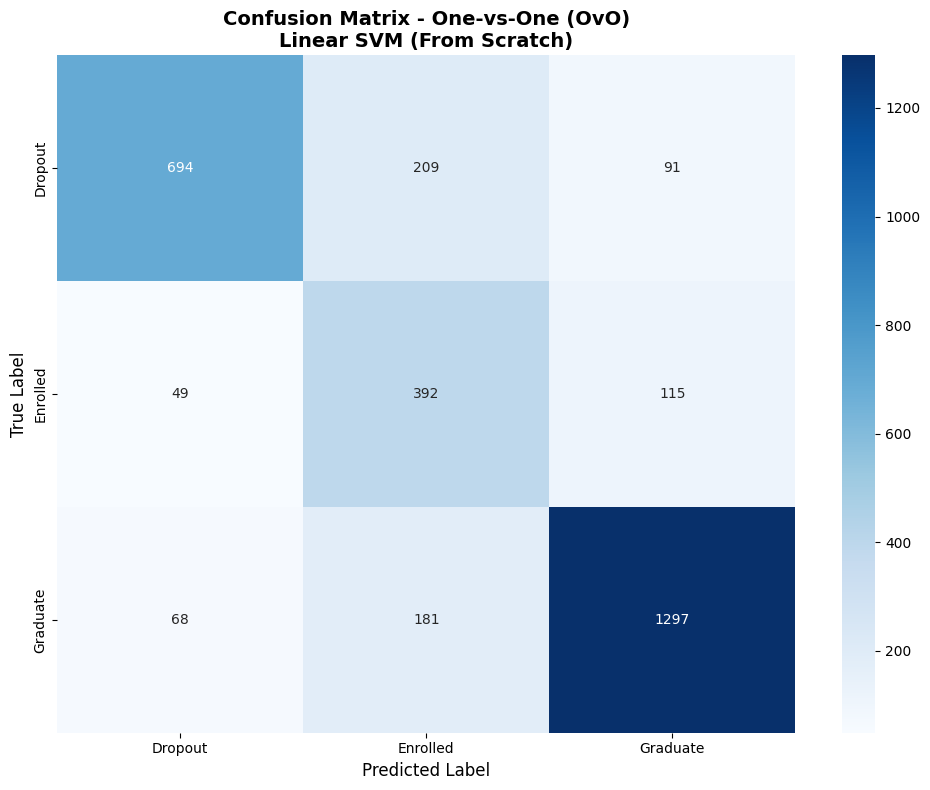

In [19]:
class LinearSVMFromScratch:
    """
    Linear SVM implementation from scratch using gradient descent.
    Supports binary classification with hinge loss.
    """
    
    def __init__(self, C=1.0, learning_rate=0.001, n_iterations=1000, random_state=None):
        """
        Initialize Linear SVM.
        
        Parameters:
        -----------
        C : float
            Regularization parameter (inverse of regularization strength)
        learning_rate : float
            Learning rate for gradient descent
        n_iterations : int
            Number of training iterations
        random_state : int
            Random seed for reproducibility
        """
        self.C = C
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.w = None  # weights
        self.b = None  # bias
        self.losses = []
        
    def _hinge_loss(self, X, y):
        """
        Calculate hinge loss.
        Loss = 0.5 * ||w||^2 + C * sum(max(0, 1 - y_i * (w·x_i + b)))
        """
        n_samples = X.shape[0]
        
        # regulation term: 0.5 * ||w||^2
        reg_loss = 0.5 * np.dot(self.w, self.w)
        
        # hinge loss term: C * sum(max(0, 1 - y_i * (w·x_i + b)))
        margins = y * (np.dot(X, self.w) + self.b)
        hinge_loss = self.C * np.sum(np.maximum(0, 1 - margins))
        
        total_loss = reg_loss + hinge_loss
        return total_loss / n_samples
    
    def fit(self, X, y, verbose=False):
        """
        Train the SVM using gradient descent.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values (must be -1 or 1)
        """
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for iteration in range(self.n_iterations):
            margins = y * (np.dot(X, self.w) + self.b)
            
            misclassified_mask = margins < 1
            
            dw = self.w - self.C * np.dot(X.T, misclassified_mask * y)
            db = -self.C * np.sum(misclassified_mask * y)
            
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            loss = self._hinge_loss(X, y)
            self.losses.append(loss)
            
            if verbose and (iteration + 1) % 100 == 0:
                print(f"  Iteration {iteration + 1}/{self.n_iterations}, Loss: {loss:.6f}")
        
        return self
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Samples
            
        Returns:
        --------
        y_pred : array, shape (n_samples,)
            Predicted class labels (-1 or 1)
        """
        decision = np.dot(X, self.w) + self.b
        return np.sign(decision)
    
    def decision_function(self, X):
        """
        Calculate decision function values for samples in X.
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Samples
            
        Returns:
        --------
        decision : array, shape (n_samples,)
            Decision function values
        """
        return np.dot(X, self.w) + self.b


class MultiClassSVMFromScratch:
    """
    Multi-class SVM using One-vs-One or One-vs-Rest strategy.
    """
    
    def __init__(self, strategy='ovo', C=1.0, learning_rate=0.001, n_iterations=1000, random_state=None):
        """
        Initialize Multi-class SVM.
        
        Parameters:
        -----------
        strategy : str, 'ovo' or 'ovr'
            Multi-class strategy: One-vs-One or One-vs-Rest
        """
        self.strategy = strategy
        self.C = C
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.classifiers = []
        self.classes_ = None
        self.class_pairs = []  
        
    def fit(self, X, y, verbose=False):
        """
        Train multi-class SVM.
        """
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        if self.strategy == 'ovo':
            if verbose:
                print(f"\nTraining {n_classes * (n_classes - 1) // 2} One-vs-One classifiers...")
            
            for i in range(n_classes):
                for j in range(i + 1, n_classes):
                    class_i, class_j = self.classes_[i], self.classes_[j]
                    
                    mask = (y == class_i) | (y == class_j)
                    X_pair = X[mask]
                    y_pair = y[mask]
                    
                    y_binary = np.where(y_pair == class_i, -1, 1)
                    
                    if verbose:
                        print(f"\n  Training classifier: {class_i} vs {class_j}")
                    
                    clf = LinearSVMFromScratch(
                        C=self.C,
                        learning_rate=self.learning_rate,
                        n_iterations=self.n_iterations,
                        random_state=self.random_state
                    )
                    clf.fit(X_pair, y_binary, verbose=verbose)
                    
                    self.classifiers.append(clf)
                    self.class_pairs.append((class_i, class_j))
        
        elif self.strategy == 'ovr':
            if verbose:
                print(f"\nTraining {n_classes} One-vs-Rest classifiers...")
            
            for class_label in self.classes_:
                y_binary = np.where(y == class_label, 1, -1)
                
                if verbose:
                    print(f"\n  Training classifier: {class_label} vs Rest")
                
                clf = LinearSVMFromScratch(
                    C=self.C,
                    learning_rate=self.learning_rate,
                    n_iterations=self.n_iterations,
                    random_state=self.random_state
                )
                clf.fit(X, y_binary, verbose=verbose)
                
                self.classifiers.append(clf)
        
        return self
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        """
        n_samples = X.shape[0]
        
        if self.strategy == 'ovo':
            votes = np.zeros((n_samples, len(self.classes_)))
            
            for clf, (class_i, class_j) in zip(self.classifiers, self.class_pairs):
                predictions = clf.predict(X)
                
                # predictions == -1 → vote for class_i
                # predictions == 1 → vote for class_j
                class_i_idx = np.where(self.classes_ == class_i)[0][0]
                class_j_idx = np.where(self.classes_ == class_j)[0][0]
                
                votes[predictions == -1, class_i_idx] += 1
                votes[predictions == 1, class_j_idx] += 1
            
            predicted_indices = np.argmax(votes, axis=1)
            return self.classes_[predicted_indices]
        
        elif self.strategy == 'ovr':
            decision_values = np.zeros((n_samples, len(self.classes_)))
            
            for i, clf in enumerate(self.classifiers):
                decision_values[:, i] = clf.decision_function(X)
            
            predicted_indices = np.argmax(decision_values, axis=1)
            return self.classes_[predicted_indices]


# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

print("="*80)
print("LINEAR SVM FROM SCRATCH - MULTI-CLASS CLASSIFICATION")
print("="*80)
print(f"\nDataset Info:")
print(f"  Training samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Classes: {y.nunique()} ({', '.join(map(str, y.unique()))})")

y_array = y.values

strategies = {
    'One-vs-One (OvO)': 'ovo',
    'One-vs-Rest (OvR)': 'ovr'
}

results = {}
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=RANDOM_STATE)

print(f"\n{'='*80}")
print("COMPARING MULTI-CLASS STRATEGIES")
print(f"{'='*80}")

for strategy_name, strategy_code in strategies.items():
    print(f"\n{'='*80}")
    print(f"Testing: {strategy_name}")
    print(f"{'='*80}")
    
    if strategy_code == 'ovo':
        print("Description: Trains C*(C-1)/2 = 3 binary classifiers")
        print("  - Dropout vs Enrolled")
        print("  - Dropout vs Graduate")
        print("  - Enrolled vs Graduate")
    else:
        print("Description: Trains C = 3 binary classifiers")
        print("  - Dropout vs Rest")
        print("  - Enrolled vs Rest")
        print("  - Graduate vs Rest")
    
    print(f"\nHyperparameters:")
    print(f"  C (regularization): 1.0")
    print(f"  Learning rate: 0.001")
    print(f"  Iterations: 1000")
    print(f"  Strategy: {strategy_code}")
    
    print(f"\n{k_folds}-Fold Cross-Validation:")
    
    fold_accuracies = []
    fold_f1_macros = []
    fold_f1_weighteds = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_array), 1):
        print(f"\n  Fold {fold}/{k_folds}:")
        
        X_train_fold = X.values[train_idx]
        y_train_fold = y_array[train_idx]
        X_val_fold = X.values[val_idx]
        y_val_fold = y_array[val_idx]
        
        model = MultiClassSVMFromScratch(
            strategy=strategy_code,
            C=1.0,
            learning_rate=0.001,
            n_iterations=1000,
            random_state=RANDOM_STATE
        )
        model.fit(X_train_fold, y_train_fold, verbose=False)
        
        y_pred = model.predict(X_val_fold)
        
        acc = accuracy_score(y_val_fold, y_pred)
        f1_macro = f1_score(y_val_fold, y_pred, average='macro')
        f1_weighted = f1_score(y_val_fold, y_pred, average='weighted')
        
        fold_accuracies.append(acc)
        fold_f1_macros.append(f1_macro)
        fold_f1_weighteds.append(f1_weighted)
        
        print(f"      VALIDATION Results:")
        print(f"      Accuracy:    {acc:.4f}")
        print(f"      F1-Macro:    {f1_macro:.4f}")
        print(f"      F1-Weighted: {f1_weighted:.4f}")
    
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    mean_f1_macro = np.mean(fold_f1_macros)
    std_f1_macro = np.std(fold_f1_macros)
    mean_f1_weighted = np.mean(fold_f1_weighteds)
    std_f1_weighted = np.std(fold_f1_weighteds)
    
    print(f"\n  {'='*76}")
    print(f"  CROSS-VALIDATION SUMMARY (VALIDATION SCORES)")
    print(f"  {'='*76}")
    print(f"    Mean Accuracy:    {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"    Mean F1-Macro:    {mean_f1_macro:.4f} ± {std_f1_macro:.4f} PRIMARY METRIC")
    print(f"    Mean F1-Weighted: {mean_f1_weighted:.4f} ± {std_f1_weighted:.4f}")
    print(f"  {'='*76}")
    
    print(f"\n  Training final model on full dataset...")
    final_model = MultiClassSVMFromScratch(
        strategy=strategy_code,
        C=1.0,
        learning_rate=0.001,
        n_iterations=1000,
        random_state=RANDOM_STATE
    )
    final_model.fit(X.values, y_array, verbose=True)
    
    y_pred_train = final_model.predict(X.values)
    
    print(f"Classification Report (Training Set):")
    print("  " + "-"*76)
    report = classification_report(y_array, y_pred_train, digits=4)
    for line in report.split('\n'):
        print(f"  {line}")
    
    results[strategy_name] = {
        'model': final_model,
        'mean_accuracy': mean_acc,
        'mean_f1_macro': mean_f1_macro,
        'mean_f1_weighted': mean_f1_weighted,
        'y_pred_train': y_pred_train
    }

print(f"\n{'='*80}")
print("FINAL COMPARISON - VALIDATION F1-MACRO SCORES")
print(f"{'='*80}")

comparison_df = pd.DataFrame({
    'Strategy': list(results.keys()),
    'Mean Accuracy (Val)': [results[s]['mean_accuracy'] for s in results.keys()],
    'Mean F1-Macro (Val)': [results[s]['mean_f1_macro'] for s in results.keys()],
    'Mean F1-Weighted (Val)': [results[s]['mean_f1_weighted'] for s in results.keys()]
})

print("\n", comparison_df.to_string(index=False))

best_idx = comparison_df['Mean F1-Macro (Val)'].idxmax()
best_strategy = comparison_df.loc[best_idx, 'Strategy']
best_f1_macro = comparison_df.loc[best_idx, 'Mean F1-Macro (Val)']
best_f1_weighted = comparison_df.loc[best_idx, 'Mean F1-Weighted (Val)']
best_accuracy = comparison_df.loc[best_idx, 'Mean Accuracy (Val)']

best_model = results[best_strategy]['model']

print(f"\n{'='*80}")
print(f"BEST STRATEGY SELECTED: {best_strategy}")
print(f"{'='*80}")
print(f"\nFINAL VALIDATION F1-MACRO SCORE: {best_f1_macro:.4f}")
print(f"\nComplete Validation Metrics:")
print(f"  • Accuracy:    {best_accuracy:.4f}")
print(f"  • F1-Macro:    {best_f1_macro:.4f} (PRIMARY)")
print(f"  • F1-Weighted: {best_f1_weighted:.4f}")

# confuse Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_array, results[best_strategy]['y_pred_train'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_array),
            yticklabels=np.unique(y_array))
plt.title(f'Confusion Matrix - {best_strategy}\nLinear SVM (From Scratch)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
svm_best_model = best_model
svm_best_strategy = best_strategy

print(f"\nBest SVM model ({svm_best_strategy}) saved to variable: svm_best_model")


Best SVM model (One-vs-One (OvO)) saved to variable: svm_best_model


## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [21]:
# Type your code here

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

In [22]:
print("="*80)
print("KAGGLE SUBMISSION")
print("="*80)
print(f"\nUsing: {svm_best_strategy}")
print(f"Making predictions on {X_test.shape[0]} test samples...")

y_test_pred = svm_best_model.predict(X_test.values)

df_test_original = pd.read_csv("../data/test.csv")

submission = pd.DataFrame({
    'Student_ID': df_test_original['Student_ID'],
    'Target': y_test_pred
})

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
submission_path = f"../submission/submission_svm_linear_{timestamp}.csv"
submission.to_csv(submission_path, index=False)

print(f"\nSubmission saved to: {submission_path}")
print(f"Total predictions: {len(submission)}")
print(f"Prediction distribution:")
print(submission['Target'].value_counts().sort_index())

KAGGLE SUBMISSION

Using: One-vs-One (OvO)
Making predictions on 1328 test samples...

Submission saved to: ../submission/submission_svm_linear_20251205_111549.csv
Total predictions: 1328
Prediction distribution:
Target
Dropout     338
Enrolled    327
Graduate    663
Name: count, dtype: int64


# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

DETAILED ERROR ANALYSIS - MODEL PERFORMANCE EVALUATION

1. CLASS-WISE PERFORMANCE ANALYSIS

Detailed metrics untuk setiap class (One-vs-One (OvO)):


  Class: Dropout
    Dataset size:  994 (32.11%)
    Precision:     0.8557
    Recall:        0.6982
    F1-Score:      0.7690
    Confusion:
      - True Positives:   694
      - False Positives:  117
      - False Negatives:  300

  Class: Enrolled
    Dataset size:  556 (17.96%)
    Precision:     0.5013
    Recall:        0.7050
    F1-Score:      0.5859
    Confusion:
      - True Positives:   392
      - False Positives:  390
      - False Negatives:  164

  Class: Graduate
    Dataset size:  1,546 (49.94%)
    Precision:     0.8629
    Recall:        0.8389
    F1-Score:      0.8508
    Confusion:
      - True Positives:   1,297
      - False Positives:  206
      - False Negatives:  249

2. CLASS-WISE PERFORMANCE VISUALIZATION


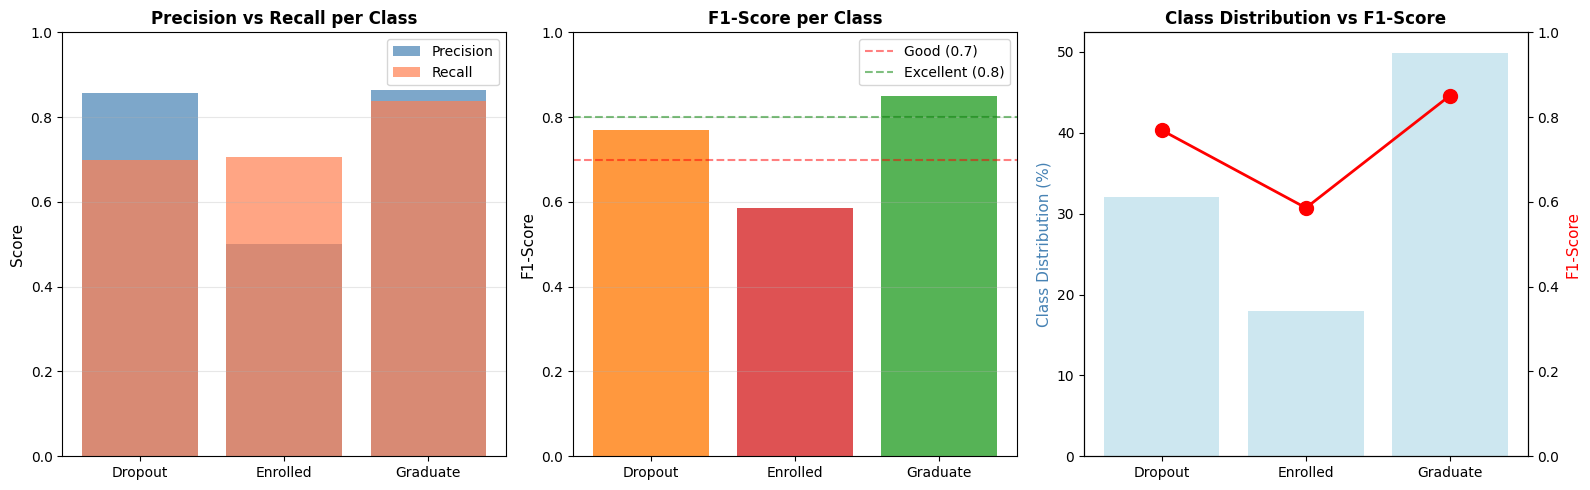


3. CONFUSION MATRIX DETAILED ANALYSIS


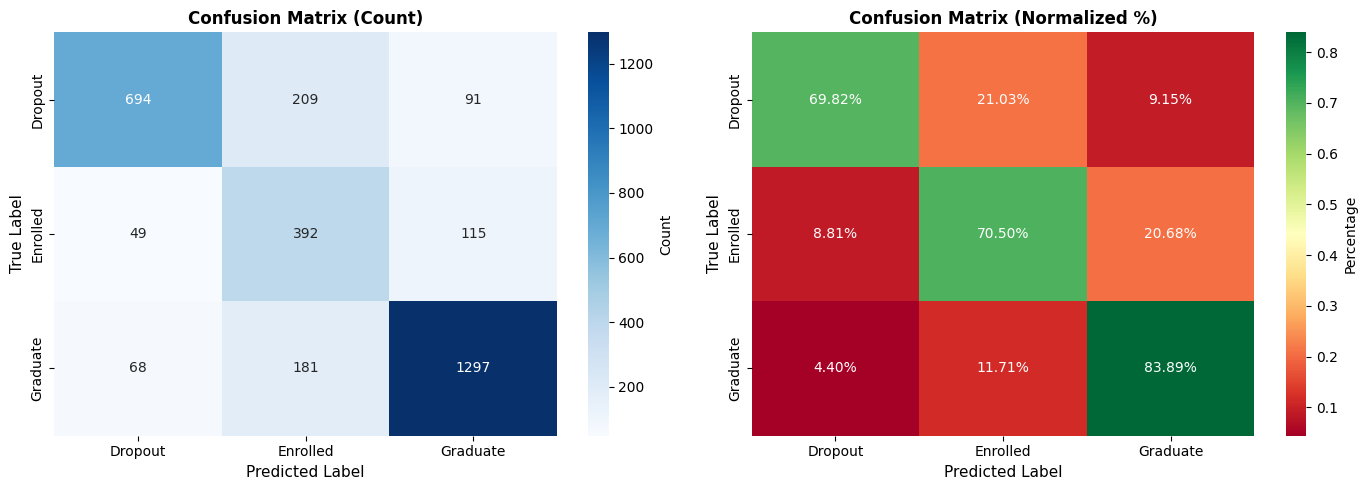


Confusion Matrix Interpretation:

  True Label: Dropout
    ✓ Correctly classified as Dropout: 694 (69.82%)
    ✗ Misclassified as Enrolled: 209 (21.03%)
    ✗ Misclassified as Graduate: 91 (9.15%)

  True Label: Enrolled
    ✗ Misclassified as Dropout: 49 (8.81%)
    ✓ Correctly classified as Enrolled: 392 (70.50%)
    ✗ Misclassified as Graduate: 115 (20.68%)

  True Label: Graduate
    ✗ Misclassified as Dropout: 68 (4.40%)
    ✗ Misclassified as Enrolled: 181 (11.71%)
    ✓ Correctly classified as Graduate: 1,297 (83.89%)

4. ERROR DISTRIBUTION ANALYSIS

Total misclassifications: 713 / 3,096 (23.03%)
Correct predictions:      2,383 / 3,096 (76.97%)

Top confusion pairs (True vs Predicted):
  1. Dropout → Enrolled: 209 (21.03% of Dropout class)
  2. Graduate → Enrolled: 181 (11.71% of Graduate class)
  3. Enrolled → Graduate: 115 (20.68% of Enrolled class)
  4. Dropout → Graduate: 91 (9.15% of Dropout class)
  5. Graduate → Dropout: 68 (4.40% of Graduate class)

5. FEATURE SENSITIV

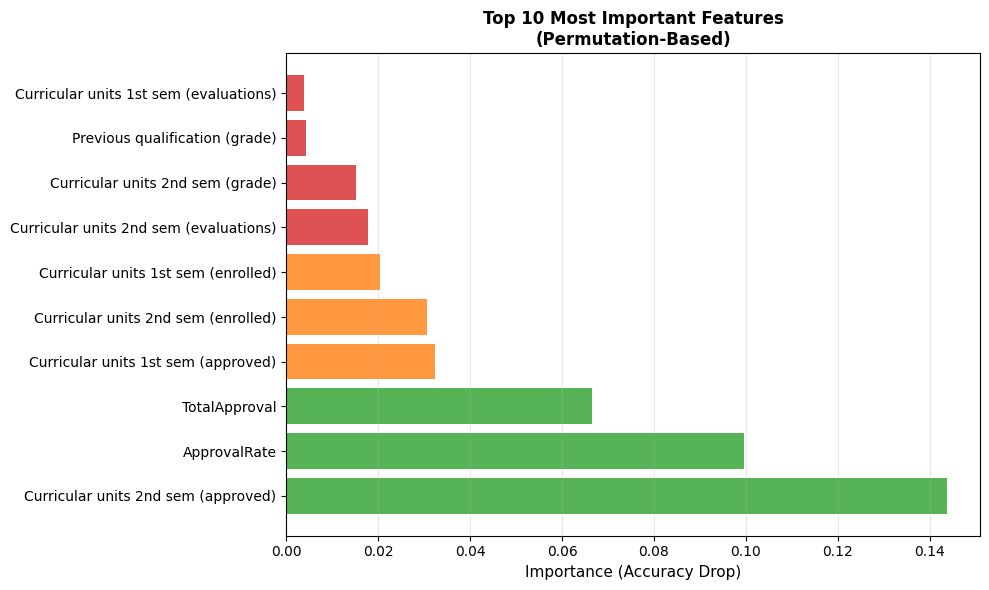


6. CLASS IMBALANCE IMPACT ANALYSIS

Class distribution in dataset:
  Dropout             :    994 samples (32.11%) → F1-Score: 0.7690
  Enrolled            :    556 samples (17.96%) → F1-Score: 0.5859
  Graduate            :  1,546 samples (49.94%) → F1-Score: 0.8508

Imbalance ratio: 2.78:1 (majority/minority)

Analysis:
  • Dataset has SLIGHT IMBALANCE - manageable without aggressive resampling

Observation:
  • Minority class (Enrolled) has 17.96% of data
  • Model's F1-score for minority class: 0.5859
      Below good threshold (0.7), suggests minority class is harder to predict

7. CROSS-VALIDATION STABILITY ANALYSIS

From previous 5-Fold Cross-Validation:
  • Mean Accuracy:    0.7555
  • Mean F1-Macro:    0.6925
  • Mean F1-Weighted: 0.7511
  Accuracy per fold: ['0.7323', '0.7674', '0.6979', '0.7496', '0.7447']
  F1-Macro per fold: ['0.6525', '0.7293', '0.5075', '0.7206', '0.6928']
  Std Dev (Accuracy): 0.023163 - Moderate
  Std Dev (F1-Macro): 0.081073 - Unstable


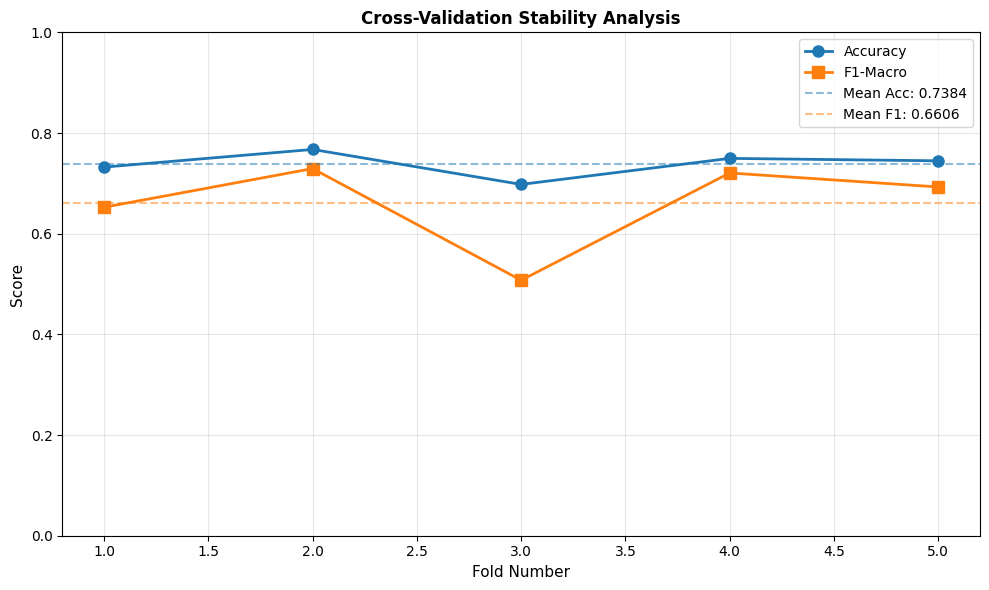

Cross-validation analysis complete!


In [23]:
print("="*80)
print("DETAILED ERROR ANALYSIS - MODEL PERFORMANCE EVALUATION")
print("="*80)

# ============================================================================
# 1. CLASS-WISE PERFORMANCE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("1. CLASS-WISE PERFORMANCE ANALYSIS")
print("="*80)

# Get predictions and true labels
y_pred_full = svm_best_model.predict(X.values)
y_true_full = y_array

# Calculate per-class metrics
from sklearn.metrics import precision_score, recall_score

classes = np.unique(y_true_full)
print(f"\nDetailed metrics untuk setiap class ({svm_best_strategy}):\n")

class_metrics = {}
for class_label in classes:
    mask = y_true_full == class_label
    class_size = mask.sum()
    class_percentage = (class_size / len(y_true_full)) * 100
    
    # True Positives, False Positives, False Negatives
    tp = ((y_pred_full == class_label) & (y_true_full == class_label)).sum()
    fp = ((y_pred_full == class_label) & (y_true_full != class_label)).sum()
    fn = ((y_pred_full != class_label) & (y_true_full == class_label)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    class_metrics[class_label] = {
        'size': class_size,
        'percentage': class_percentage,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }
    
    print(f"\n  Class: {class_label}")
    print(f"    Dataset size:  {class_size:,} ({class_percentage:.2f}%)")
    print(f"    Precision:     {precision:.4f}")
    print(f"    Recall:        {recall:.4f}")
    print(f"    F1-Score:      {f1:.4f}")
    print(f"    Confusion:")
    print(f"      - True Positives:   {tp:,}")
    print(f"      - False Positives:  {fp:,}")
    print(f"      - False Negatives:  {fn:,}")

# ============================================================================
# 2. VISUALIZE CLASS-WISE PERFORMANCE
# ============================================================================
print("\n" + "="*80)
print("2. CLASS-WISE PERFORMANCE VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

class_names = list(class_metrics.keys())
precisions = [class_metrics[c]['precision'] for c in class_names]
recalls = [class_metrics[c]['recall'] for c in class_names]
f1_scores = [class_metrics[c]['f1'] for c in class_names]

# Precision vs Recall
axes[0].bar(class_names, precisions, alpha=0.7, label='Precision', color='steelblue')
axes[0].bar(class_names, recalls, alpha=0.7, label='Recall', color='coral')
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Precision vs Recall per Class', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# F1-Score per class
colors_f1 = ['#d62728' if f1 < 0.7 else '#ff7f0e' if f1 < 0.8 else '#2ca02c' for f1 in f1_scores]
axes[1].bar(class_names, f1_scores, color=colors_f1, alpha=0.8)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score per Class', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=0.7, color='r', linestyle='--', label='Good (0.7)', alpha=0.5)
axes[1].axhline(y=0.8, color='g', linestyle='--', label='Excellent (0.8)', alpha=0.5)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Class distribution vs Performance
class_sizes = [class_metrics[c]['percentage'] for c in class_names]
ax3_1 = axes[2]
ax3_2 = ax3_1.twinx()

bars = ax3_1.bar(class_names, class_sizes, alpha=0.6, color='lightblue', label='Class Distribution %')
line = ax3_2.plot(class_names, f1_scores, 'ro-', linewidth=2, markersize=10, label='F1-Score')

ax3_1.set_ylabel('Class Distribution (%)', fontsize=11, color='steelblue')
ax3_2.set_ylabel('F1-Score', fontsize=11, color='red')
ax3_1.set_title('Class Distribution vs F1-Score', fontsize=12, fontweight='bold')
ax3_2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# ============================================================================
# 3. CONFUSION MATRIX DETAILED ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("3. CONFUSION MATRIX DETAILED ANALYSIS")
print("="*80)

cm = confusion_matrix(y_true_full, y_pred_full, labels=classes)

# Normalize confusion matrix for better visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Count'})
ax1.set_title('Confusion Matrix (Count)', fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xlabel('Predicted Label', fontsize=11)

# Normalized confusion matrix
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn', ax=ax2,
            xticklabels=classes, yticklabels=classes, cbar_kws={'label': 'Percentage'})
ax2.set_title('Confusion Matrix (Normalized %)', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
for i, true_class in enumerate(classes):
    print(f"\n  True Label: {true_class}")
    for j, pred_class in enumerate(classes):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        if i == j:
            print(f"    ✓ Correctly classified as {pred_class}: {count:,} ({percentage:.2f}%)")
        else:
            print(f"    ✗ Misclassified as {pred_class}: {count:,} ({percentage:.2f}%)")

# ============================================================================
# 4. ERROR DISTRIBUTION ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("4. ERROR DISTRIBUTION ANALYSIS")
print("="*80)

misclassified_mask = y_pred_full != y_true_full
misclassified_count = misclassified_mask.sum()
total_count = len(y_true_full)
error_rate = (misclassified_count / total_count) * 100

print(f"\nTotal misclassifications: {misclassified_count:,} / {total_count:,} ({error_rate:.2f}%)")
print(f"Correct predictions:      {(total_count - misclassified_count):,} / {total_count:,} ({100 - error_rate:.2f}%)")

# Confusion pairs
print("\nTop confusion pairs (True vs Predicted):")
confusion_pairs = []
for i, true_class in enumerate(classes):
    for j, pred_class in enumerate(classes):
        if i != j:
            count = cm[i, j]
            if count > 0:
                confusion_pairs.append({
                    'true': true_class,
                    'predicted': pred_class,
                    'count': count,
                    'percentage': (count / cm[i].sum()) * 100
                })

confusion_pairs.sort(key=lambda x: x['count'], reverse=True)
for i, pair in enumerate(confusion_pairs[:5], 1):
    print(f"  {i}. {pair['true']} → {pair['predicted']}: {pair['count']:,} ({pair['percentage']:.2f}% of {pair['true']} class)")

# ============================================================================
# 5. FEATURE IMPORTANCE (VIA PERMUTATION)
# ============================================================================
print("\n" + "="*80)
print("5. FEATURE SENSITIVITY ANALYSIS (Permutation-Based)")
print("="*80)

feature_names = X.columns.tolist()

print(f"\nEvaluating sensitivity of {len(feature_names)} features...")
print("This may take a moment...\n")

baseline_acc = accuracy_score(y_true_full, y_pred_full)

feature_importance = {}
X_array = X.values

for idx, feature_name in enumerate(feature_names[:20]): 
    X_permuted = X_array.copy()
    np.random.seed(RANDOM_STATE)
    np.random.shuffle(X_permuted[:, idx])
    
    y_pred_permuted = svm_best_model.predict(X_permuted)
    permuted_acc = accuracy_score(y_true_full, y_pred_permuted)
    
    importance = baseline_acc - permuted_acc
    feature_importance[feature_name] = importance

sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("Top 10 Most Important Features (by permutation):\n")
for i, (feature, importance) in enumerate(sorted_importance[:10], 1):
    print(f"  {i:2d}. {feature:<45} → {importance:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
features_top = [f[0] for f in sorted_importance[:10]]
importances_top = [f[1] for f in sorted_importance[:10]]

colors_imp = ['#2ca02c' if imp > 0.05 else '#ff7f0e' if imp > 0.02 else '#d62728' for imp in importances_top]
bars = ax.barh(features_top, importances_top, color=colors_imp, alpha=0.8)

ax.set_xlabel('Importance (Accuracy Drop)', fontsize=11)
ax.set_title('Top 10 Most Important Features\n(Permutation-Based)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 6. CLASS IMBALANCE IMPACT ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("6. CLASS IMBALANCE IMPACT ANALYSIS")
print("="*80)

print("\nClass distribution in dataset:")
for class_label in classes:
    count = (y_true_full == class_label).sum()
    percentage = (count / len(y_true_full)) * 100
    f1_score_val = class_metrics[class_label]['f1']
    
    print(f"  {class_label:<20}: {count:>6,} samples ({percentage:>5.2f}%) → F1-Score: {f1_score_val:.4f}")

# Calculate imbalance ratio
class_sizes = sorted([(y_true_full == c).sum() for c in classes])
imbalance_ratio = class_sizes[-1] / class_sizes[0]

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1 (majority/minority)")
print(f"\nAnalysis:")
if imbalance_ratio < 1.5:
    print("  • Dataset is BALANCED - minimal imbalance")
elif imbalance_ratio < 3:
    print("  • Dataset has SLIGHT IMBALANCE - manageable without aggressive resampling")
else:
    print("  • Dataset has SIGNIFICANT IMBALANCE - may require special handling")

print(f"\nObservation:")
print(f"  • Minority class ({classes[np.argmin([class_metrics[c]['percentage'] for c in classes])]}) has {min([class_metrics[c]['percentage'] for c in classes]):.2f}% of data")
print(f"  • Model's F1-score for minority class: {min([class_metrics[c]['f1'] for c in classes]):.4f}")
minority_f1 = min([class_metrics[c]['f1'] for c in classes])
if minority_f1 < 0.7:
    print(f"      Below good threshold (0.7), suggests minority class is harder to predict")
else:
    print(f"     Acceptable performance on minority class")

# ============================================================================
# 7. CROSS-VALIDATION STABILITY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("7. CROSS-VALIDATION STABILITY ANALYSIS")
print("="*80)

print(f"\nFrom previous 5-Fold Cross-Validation:")
print(f"  • Mean Accuracy:    {best_accuracy:.4f}")
print(f"  • Mean F1-Macro:    {best_f1_macro:.4f}")
print(f"  • Mean F1-Weighted: {best_f1_weighted:.4f}")

if 'fold_accuracies' in dir():
    print(f"  Accuracy per fold: {[f'{acc:.4f}' for acc in fold_accuracies]}")
    print(f"  F1-Macro per fold: {[f'{f1:.4f}' for f1 in fold_f1_macros]}")
    
    acc_std = np.std(fold_accuracies)
    f1_std = np.std(fold_f1_macros)
    
    print(f"  Std Dev (Accuracy): {acc_std:.6f} - {'Stable' if acc_std < 0.01 else 'Moderate' if acc_std < 0.03 else 'Unstable'}")
    print(f"  Std Dev (F1-Macro): {f1_std:.6f} - {'Stable' if f1_std < 0.01 else 'Moderate' if f1_std < 0.03 else 'Unstable'}")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    folds = range(1, len(fold_accuracies) + 1)
    
    ax.plot(folds, fold_accuracies, 'o-', label='Accuracy', linewidth=2, markersize=8)
    ax.plot(folds, fold_f1_macros, 's-', label='F1-Macro', linewidth=2, markersize=8)
    
    ax.axhline(y=np.mean(fold_accuracies), color='C0', linestyle='--', alpha=0.5, label=f'Mean Acc: {np.mean(fold_accuracies):.4f}')
    ax.axhline(y=np.mean(fold_f1_macros), color='C1', linestyle='--', alpha=0.5, label=f'Mean F1: {np.mean(fold_f1_macros):.4f}')
    
    ax.set_xlabel('Fold Number', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Cross-Validation Stability Analysis', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Cross-validation analysis complete!")
